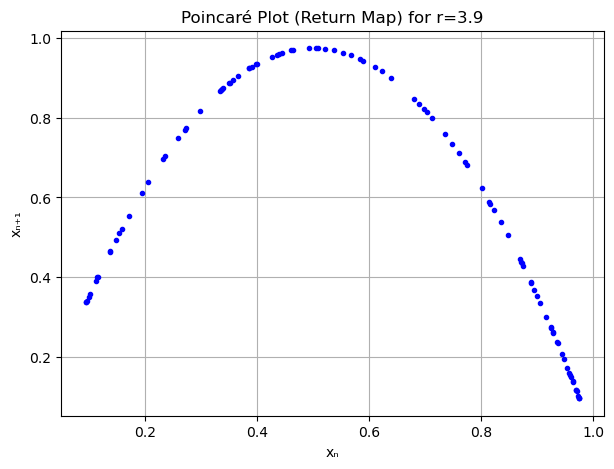

In [5]:
import tkinter as tk
from tkinter import ttk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np

def plot_logistic_map():
    try:
        r = float(entry_r.get())
        x0 = float(entry_x0.get())
        iterations = int(entry_iterations.get())
    except ValueError:
        return
    
    fig.clf()
    ax = fig.add_subplot(111)

    x_vals = [x0]
    
    for _ in range(iterations):
        x_next = r * x_vals[-1] * (1 - x_vals[-1])
        x_vals.append(x_next)
    
    ax.plot(range(len(x_vals)), x_vals, marker='o', linestyle='dotted', color='red', markersize=3)
    ax.set_title(f"Logistic Map Time Series: xₙ₊₁ = r·xₙ·(1 - xₙ) for r={r}")
    ax.set_xlabel("Iteration (n)")
    ax.set_ylabel("xₙ")
    ax.grid(True)
    canvas.draw()

def plot_poincare_map():
    try:
        r = float(entry_r.get())
        x0 = float(entry_x0.get())
        iterations = int(entry_iterations.get())
    except ValueError:
        return

    fig.clf()
    ax = fig.add_subplot(111)
    
    x_vals = [x0]
    
    for _ in range(iterations):
        x_next = r * x_vals[-1] * (1 - x_vals[-1])
        x_vals.append(x_next)

    x_n = x_vals[:-1]
    x_n_plus_1 = x_vals[1:]
    
    ax.plot(x_n, x_n_plus_1, 'o', color='blue', markersize=3)
    ax.set_title(f"Poincaré Plot (Return Map) for r={r}")
    ax.set_xlabel("xₙ")
    ax.set_ylabel("xₙ₊₁")
    ax.grid(True)
    canvas.draw()

def clear_plot():
    fig.clf()
    canvas.draw()

# Main Window
root = tk.Tk()
root.title("Logistic Map Visualizer")
root.geometry("800x700")
root.configure(padx=10, pady=10)

# Input Fields
ttk.Label(root, text="Enter r value:").grid(row=0, column=0, sticky='w')
entry_r = ttk.Entry(root)
entry_r.insert(0, "3.5")
entry_r.grid(row=0, column=1, sticky='ew')

ttk.Label(root, text="Enter x₀ value:").grid(row=1, column=0, sticky='w')
entry_x0 = ttk.Entry(root)
entry_x0.insert(0, "0.1")
entry_x0.grid(row=1, column=1, sticky='ew')

ttk.Label(root, text="Enter number of iterations:").grid(row=2, column=0, sticky='w')
entry_iterations = ttk.Entry(root)
entry_iterations.insert(0, "100")
entry_iterations.grid(row=2, column=1, sticky='ew')

# Buttons
plot_time_series_button = ttk.Button(root, text="Plot Time Series", command=plot_logistic_map)
plot_time_series_button.grid(row=3, column=0, pady=5)

plot_poincare_button = ttk.Button(root, text="Plot Poincaré Map", command=plot_poincare_map)
plot_poincare_button.grid(row=3, column=1, pady=5)

clear_button = ttk.Button(root, text="Clear", command=clear_plot)
clear_button.grid(row=4, column=0, columnspan=2, pady=5)

# Plotting Area
fig = plt.figure(figsize=(7, 5))
canvas = FigureCanvasTkAgg(fig, master=root)
canvas.get_tk_widget().grid(row=5, column=0, columnspan=2, pady=10)

root.mainloop()